# Paper replication — data splits, preprocessing & feature engineering

Replicates **sections 3–5** of [`paper/replicate/replication_guide.md`](../../paper/replicate/replication_guide.md)
(Panda & Mohanty, *IEEE Access* 2023, DOI [10.1109/ACCESS.2023.3266275](https://doi.org/10.1109/ACCESS.2023.3266275)).

**What the paper forecasts** (guide §1): weekly `num_orders` for the **next 10 weeks** (weeks 136–145),
framed as a regression problem and **evaluated per meal** with metrics averaged across meals.
That framing drives everything below:

| Guide section | What this notebook builds |
|---|---|
| §3 Data splits | ML: train weeks 1–135 / test 136–145 · DL: 13–125 train / 126–135 val / 136–145 test |
| §4 Preprocessing | merge 3 CSVs → drop nulls → remove the single `num_orders` outlier → drop `checkout_price` (correlated with `base_price`) → quantile transform → standardize → label-encode |
| §5.1 Lag features | 10 weekly lags of `num_orders` |
| §5.2 EWMA | `EWMA(w) = α·x(w) + (1−α)·EWMA(w−1)`, α = 0.5, on past target values |
| §5.3 Discount | `base_price − checkout_price` |
| §5.4 Aggregates | the 23 count / rank / price-stat features used by the ML models |

Artifacts are written to `data/processed/replicate_paper/` for the modeling notebooks that follow.

## 0 · Setup and paper constants

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import (LabelEncoder, QuantileTransformer,
                                   PowerTransformer, StandardScaler)

pd.set_option("display.max_columns", 60)

# locate repo root (works from notebooks/replicate_paper_Res/, the repo root, or a Colab clone)
ROOT = Path.cwd()
while not (ROOT / "data" / "raw" / "train.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
OUT = ROOT / "data" / "processed" / "replicate_paper"
OUT.mkdir(parents=True, exist_ok=True)

# ---- constants fixed by the paper (guide sections 3 and 5) ----
LAGS = 10                                       # lags: previous 10 weeks of num_orders
ALPHA = 0.5                                     # EWMA smoothing factor (paper Eq. 1)
ML_TRAIN_END = 135                              # ML models: train on weeks 1-135
TEST_START, TEST_END = 136, 145                 # both families: test on weeks 136-145
DL_START, DL_TRAIN_END, DL_VAL_END = 13, 125, 135   # DL: 13-125 train, 126-135 val
SEED = 42

print("repo root:", ROOT)

repo root: E:\Alireza\Article_forecast


## 1 · Load & merge the three CSVs *(preprocessing step 1)*

`train.csv` + `fulfilment_center_info.csv` (on `center_id`) + `meal_info.csv` (on `meal_id`).

In [2]:
orders = pd.read_csv(RAW / "train.csv")
centers = pd.read_csv(RAW / "fulfilment_center_info.csv")
meals = pd.read_csv(RAW / "meal_info.csv")

df = (orders
      .merge(centers, on="center_id", how="left")
      .merge(meals, on="meal_id", how="left"))

print(f"orders {orders.shape} + centers {centers.shape} + meals {meals.shape} -> merged {df.shape}")
df.head()

orders (456548, 9) + centers (77, 5) + meals (51, 3) -> merged (456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


## 2 · Remove nulls and the `num_orders` outlier *(preprocessing steps 2–3)*

The paper's box plot shows a single extreme `num_orders` value (mass at 0–1000, spread > 20 000)
attributed to a data-entry error — exactly **one row** is removed.

null values: 0


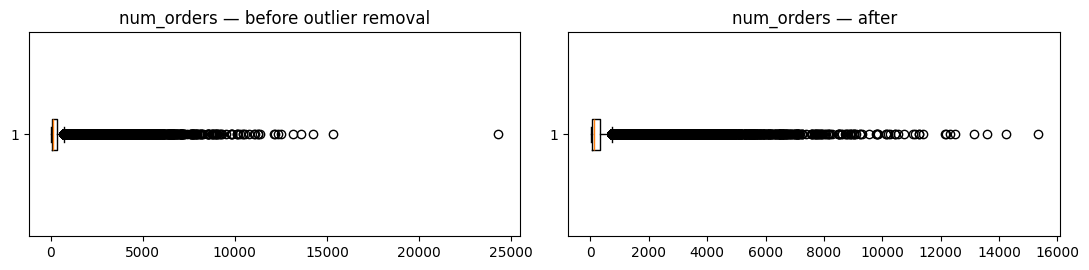

removed 1 outlier row(s): num_orders = [24299]
rows remaining: 456,547


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
14050,1452474,5,43,2290,159.08,311.43,1,1,24299,590,56,TYPE_A,5.1,Rice Bowl,Indian


In [3]:
assert df.isna().sum().sum() == 0, "unexpected nulls after merge"
print("null values:", df.isna().sum().sum())

fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
axes[0].boxplot(df["num_orders"], vert=False)
axes[0].set_title("num_orders — before outlier removal")

outliers = df[df["num_orders"] > 20000]
df = df[df["num_orders"] <= 20000].copy()

axes[1].boxplot(df["num_orders"], vert=False)
axes[1].set_title("num_orders — after")
plt.tight_layout()
plt.show()

print(f"removed {len(outliers)} outlier row(s): num_orders = {outliers['num_orders'].tolist()}")
print(f"rows remaining: {len(df):,}")
outliers

## 3 · `checkout_price` vs `base_price` *(preprocessing step 4)*

The paper's heat-map/scatter shows the two prices are highly correlated, so `checkout_price`
is **dropped as a raw model input**. We keep the column around until feature engineering is done —
`discount` (§5.3) and `meal_price_max/mean/min` (§5.4) are derived from it — and exclude it from
the final feature matrix instead.

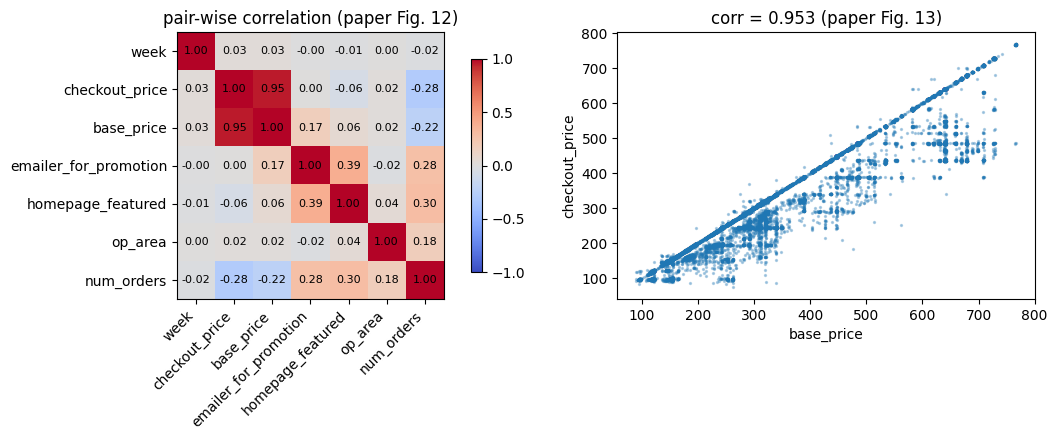

In [4]:
num_cols = ["week", "checkout_price", "base_price", "emailer_for_promotion",
            "homepage_featured", "op_area", "num_orders"]
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.3, 1]})
im = axes[0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
axes[0].set_yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        axes[0].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].set_title("pair-wise correlation (paper Fig. 12)")

sample = df.sample(20000, random_state=SEED)
axes[1].scatter(sample["base_price"], sample["checkout_price"], s=2, alpha=0.3)
axes[1].set_xlabel("base_price"); axes[1].set_ylabel("checkout_price")
axes[1].set_title(f"corr = {df['base_price'].corr(df['checkout_price']):.3f} (paper Fig. 13)")
plt.tight_layout()
plt.show()

## 4 · Feature engineering — §5.3 discount

`discount = base_price − checkout_price`. The paper checked it against `num_orders`
(their Fig. 14) and found **no strong link** — we reproduce that check.

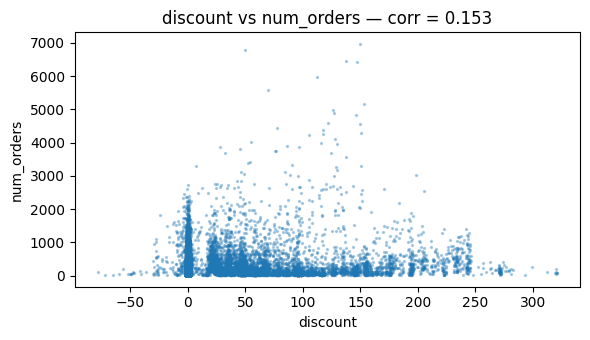

In [5]:
df["discount"] = df["base_price"] - df["checkout_price"]

fig, ax = plt.subplots(figsize=(6, 3.5))
sample = df.sample(20000, random_state=SEED)
ax.scatter(sample["discount"], sample["num_orders"], s=2, alpha=0.3)
ax.set_xlabel("discount"); ax.set_ylabel("num_orders")
ax.set_title(f"discount vs num_orders — corr = {df['discount'].corr(df['num_orders']):.3f}")
plt.tight_layout()
plt.show()

## 5 · Feature engineering — §5.4 the 23 aggregate / rank features

Three groups, exactly as listed in the guide:

* **6 price stats** — `base_price_{max,mean,min}` per meal (base price), `meal_price_{max,mean,min}` per meal (checkout price, per the paper's wording).
* **10 count features** — "count of orders" per group. Interpreted as **sum of `num_orders`** within the group, matching how the paper's own EDA counts orders (their Figs. 4–11 sum orders). `type_meal_week_count` is grouped by `center_type` per its name (the paper's prose says "center", contradicting its own name — flagged in guide §11).
* **7 price ranks** — dense rank of the row's `base_price` within a scope (the paper: "rank of a meal based on its base price").

> ⚠️ **Leakage warning (guide §11.1):** count features are aggregates of the *target* computed over the
> **full 145 weeks**, exactly as the paper describes them — so target information from the test weeks
> leaks into these columns. This is faithful to the paper, but it is one reason their tree-model numbers
> should be read skeptically. Set `COUNT_MODE = "rows"` for a leakage-reduced variant (row counts
> instead of order sums).

In [6]:
COUNT_MODE = "sum"   # "sum"  = sum of num_orders per group (paper-faithful)
                     # "rows" = number of rows per group (leakage-reduced alternative)

# ---- 6 price stats -------------------------------------------------------
g = df.groupby("meal_id")["base_price"]
df["base_price_max"] = g.transform("max")
df["base_price_mean"] = g.transform("mean")
df["base_price_min"] = g.transform("min")

g = df.groupby("meal_id")["checkout_price"]
df["meal_price_max"] = g.transform("max")
df["meal_price_mean"] = g.transform("mean")
df["meal_price_min"] = g.transform("min")

# ---- 10 count features ----------------------------------------------------
COUNT_SPECS = {
    "center_cat_count":       ["center_id", "category"],
    "center_cat_week_count":  ["center_id", "category", "week"],
    "center_cui_count":       ["center_id", "cuisine"],
    "center_week_count":      ["center_id", "week"],
    "city_meal_week_count":   ["city_code", "meal_id", "week"],
    "meal_count":             ["meal_id"],
    "meal_week_count":        ["meal_id", "week"],
    "region_meal_count":      ["region_code", "meal_id"],
    "region_meal_week_count": ["region_code", "meal_id", "week"],
    "type_meal_week_count":   ["center_type", "meal_id", "week"],
}
for name, keys in COUNT_SPECS.items():
    if COUNT_MODE == "sum":
        df[name] = df.groupby(keys)["num_orders"].transform("sum")
    else:
        df[name] = df.groupby(keys)["num_orders"].transform("size")

# ---- 7 price ranks ---------------------------------------------------------
RANK_SPECS = {
    "center_cat_price_rank":  ["center_id", "category"],
    "center_price_rank":      ["center_id"],
    "center_week_price_rank": ["center_id", "week"],
    "meal_city_price_rank":   ["city_code"],
    "meal_region_price_rank": ["region_code"],
    "meal_week_price_rank":   ["week"],
}
for name, keys in RANK_SPECS.items():
    df[name] = df.groupby(keys)["base_price"].rank(method="dense")
df["meal_price_rank"] = df["base_price"].rank(method="dense")   # global rank

AGG_FEATURES = (["base_price_max", "base_price_mean", "base_price_min",
                 "meal_price_max", "meal_price_mean", "meal_price_min"]
                + list(COUNT_SPECS) + list(RANK_SPECS) + ["meal_price_rank"])
assert len(AGG_FEATURES) == 23, len(AGG_FEATURES)
print(f"created {len(AGG_FEATURES)} aggregate features (COUNT_MODE={COUNT_MODE!r})")
df[AGG_FEATURES].describe().T[["mean", "std", "min", "max"]].round(1)

created 23 aggregate features (COUNT_MODE='sum')


,mean,std,min,max
base_price_max,441.5,181.5,165.9,866.3
base_price_mean,354.2,157.5,129.5,665.3
base_price_min,241.2,128.4,55.4,485.0
meal_price_max,438.0,182.5,165.9,866.3
meal_price_mean,332.2,145.4,126.0,611.4
meal_price_min,159.8,101.1,3.0,407.4
center_cat_count,220874.6,261805.4,14.0,1468872.0
center_cat_week_count,1543.8,1939.8,13.0,22007.0
center_cui_count,420859.5,264234.3,34096.0,1554898.0
center_week_count,11277.3,5844.0,987.0,42733.0


## 6 · Feature engineering — §5.1 lag features

`num_orders` from the **previous 10 weeks**. Two replication decisions the paper leaves open (guide §11):

1. **Granularity** — the ML matrix is row-level `(week, center, meal)`, so lags are built per
   `(center_id, meal_id)` series. (The per-meal DL series gets its own lags in §9.)
2. **Week alignment** — lags are joined on `week − k`, not on the previous *observed* row, so a gap in
   a series yields `NaN` rather than silently pulling an older week. Weeks 1–10 therefore have missing
   lags (the paper never says how ML models handled those rows; LightGBM/XGBoost accept NaNs,
   sklearn's RF/GBR do not — the modeling notebook must drop or fill them).

In [7]:
base = df[["center_id", "meal_id", "week", "num_orders"]]
for k in range(1, LAGS + 1):
    lag = base.copy()
    lag["week"] = lag["week"] + k          # value from week w becomes lag_k of week w+k
    lag = lag.rename(columns={"num_orders": f"lag_{k}"})
    df = df.merge(lag, on=["center_id", "meal_id", "week"], how="left")

LAG_COLS = [f"lag_{k}" for k in range(1, LAGS + 1)]
nan_share = df[LAG_COLS].isna().mean()
print("NaN share per lag column (early weeks + series gaps):")
print(nan_share.round(3).to_string())

NaN share per lag column (early weeks + series gaps):
lag_1     0.055
lag_2     0.064
lag_3     0.072
lag_4     0.080
lag_5     0.087
lag_6     0.095
lag_7     0.102
lag_8     0.109
lag_9     0.116
lag_10    0.123


## 7 · Feature engineering — §5.2 EWMA

$$EWMA(w) = \alpha \cdot x(w) + (1-\alpha) \cdot EWMA(w-1), \qquad \alpha = 0.5$$

The paper computes EWMA **"for lag values"** (its Novelty section), i.e. over *past* targets — so the
series is shifted by one week before smoothing: the feature at week *w* summarizes weeks ≤ *w−1* and
never sees its own target. Computed per `(center_id, meal_id)` over observed rows (gaps in a series
are smoothed over rather than NaN-ed — the recursive form has no natural week-gap handling).

In [8]:
df = df.sort_values(["center_id", "meal_id", "week"]).reset_index(drop=True)
df["ewma"] = (df.groupby(["center_id", "meal_id"])["num_orders"]
                .transform(lambda s: s.shift(1).ewm(alpha=ALPHA).mean()))

n_series = df.groupby(["center_id", "meal_id"]).ngroups
print(f"ewma NaNs: {df['ewma'].isna().sum():,} (= first row of each of the {n_series:,} center-meal series)")

# sanity check on one series: reproduce the recursion by hand
s = df[(df.center_id == 55) & (df.meal_id == 1885)].head(4)
x = s["num_orders"].to_numpy(dtype=float)
manual = [np.nan, x[0], ALPHA * x[1] + (1 - ALPHA) * x[0]]
manual.append(ALPHA * x[2] + (1 - ALPHA) * manual[2])
pd.DataFrame({"week": s["week"].values, "num_orders": x,
              "ewma (pandas)": s["ewma"].round(2).values,
              "ewma (manual recursion)": np.round(manual, 2)})

ewma NaNs: 3,597 (= first row of each of the 3,597 center-meal series)


,week,num_orders,ewma (pandas),ewma (manual recursion)
0,1,177.0,NaN,NaN
1,2,323.0,177.00,177.0
2,3,96.0,274.33,250.0
3,4,163.0,172.43,173.0


## 8 · Encoding, skewness correction & standardization *(preprocessing steps 5–7)*

* **Label encoding** for `center_type`, `category`, `cuisine` (sklearn assigns integers by sorted
  order = the paper's "alphabetical ordering"). ID-like columns are already integers.
* **Quantile vs power transform** — the paper compared both on the right-skewed numericals and chose
  the **quantile transform** (their Fig. 15, reproduced below), followed by **standardization**.
* **Deviation from the paper (deliberate):** the paper never says what the transforms were fitted on;
  we fit on the **ML train weeks (1–135) only** and apply everywhere, to keep the test window honest.
* The target `num_orders` is left untouched — the paper says nothing about transforming it (guide §11.3).

In [9]:
encoders = {}
for col in ["center_type", "category", "cuisine"]:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    encoders[col] = list(le.classes_)
    print(f"{col}: {dict(enumerate(le.classes_))}")

center_type: {0: 'TYPE_A', 1: 'TYPE_B', 2: 'TYPE_C'}
category: {0: 'Beverages', 1: 'Biryani', 2: 'Desert', 3: 'Extras', 4: 'Fish', 5: 'Other Snacks', 6: 'Pasta', 7: 'Pizza', 8: 'Rice Bowl', 9: 'Salad', 10: 'Sandwich', 11: 'Seafood', 12: 'Soup', 13: 'Starters'}


cuisine: {0: 'Continental', 1: 'Indian', 2: 'Italian', 3: 'Thai'}


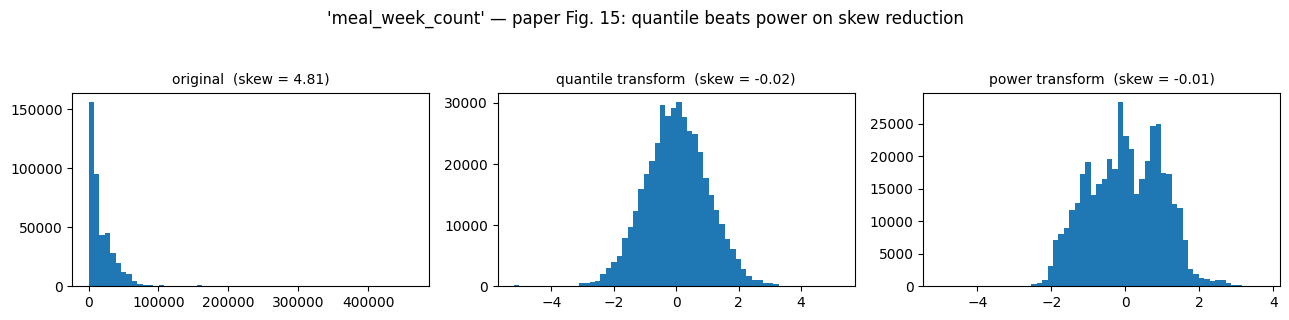

In [10]:
# reproduce the paper's Fig. 15 on one heavily right-skewed engineered feature
feat = "meal_week_count"
raw_vals = df.loc[df["week"] <= ML_TRAIN_END, [feat]]
qt_vals = QuantileTransformer(output_distribution="normal", n_quantiles=1000,
                              random_state=SEED).fit_transform(raw_vals)
pt_vals = PowerTransformer().fit_transform(raw_vals)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, vals, title in zip(
        axes, [raw_vals.to_numpy(), qt_vals, pt_vals],
        [f"original  (skew = {raw_vals[feat].skew():.2f})",
         f"quantile transform  (skew = {pd.Series(qt_vals.ravel()).skew():.2f})",
         f"power transform  (skew = {pd.Series(pt_vals.ravel()).skew():.2f})"]):
    ax.hist(vals, bins=60)
    ax.set_title(title, fontsize=10)
fig.suptitle(f"'{feat}' — paper Fig. 15: quantile beats power on skew reduction", y=1.05)
plt.tight_layout()
plt.show()

In [11]:
TARGET = "num_orders"
BINARY = ["emailer_for_promotion", "homepage_featured"]           # kept as 0/1
ID_COLS = ["id", "week", "center_id", "meal_id", "city_code", "region_code",
           "center_type_enc", "category_enc", "cuisine_enc"]      # keys + label-encoded
NUMERIC = ["base_price", "discount", "op_area"] + AGG_FEATURES + LAG_COLS + ["ewma"]
# checkout_price is intentionally absent (preprocessing step 4)

matrix = df[ID_COLS + BINARY + NUMERIC + [TARGET]].copy()

train_mask = matrix["week"] <= ML_TRAIN_END
qt = QuantileTransformer(output_distribution="normal", n_quantiles=1000, random_state=SEED)
sc = StandardScaler()
qt.fit(matrix.loc[train_mask, NUMERIC])
sc.fit(qt.transform(matrix.loc[train_mask, NUMERIC]))

matrix_t = matrix.copy()
matrix_t[NUMERIC] = sc.transform(qt.transform(matrix[NUMERIC]))

skew_before = matrix.loc[train_mask, NUMERIC].skew()
skew_after = matrix_t.loc[train_mask, NUMERIC].skew()
print(f"feature matrix: {matrix.shape} | transformed numericals: {len(NUMERIC)}")
print(f"mean |skew| before: {skew_before.abs().mean():.2f} -> after: {skew_after.abs().mean():.2f}")
matrix_t.head(3)

feature matrix: (456547, 49) | transformed numericals: 37
mean |skew| before: 3.11 -> after: 0.67


,id,week,center_id,meal_id,city_code,region_code,center_type_enc,category_enc,cuisine_enc,emailer_for_promotion,homepage_featured,base_price,discount,op_area,base_price_max,base_price_mean,base_price_min,meal_price_max,meal_price_mean,meal_price_min,center_cat_count,center_cat_week_count,center_cui_count,center_week_count,city_meal_week_count,meal_count,meal_week_count,region_meal_count,region_meal_week_count,type_meal_week_count,center_cat_price_rank,center_price_rank,center_week_price_rank,meal_city_price_rank,meal_region_price_rank,meal_week_price_rank,meal_price_rank,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,ewma,num_orders
0,1436842,1,10,1062,590,56,1,0,2,0,0,-1.039673,-0.333482,0.93859,-0.756726,-0.880277,-0.564298,-0.756084,-0.758056,-0.189116,2.074565,2.316244,1.880191,1.832002,1.709342,0.528131,0.757112,1.177924,1.271118,0.317872,0.693813,-1.067581,-0.880058,-0.962364,-1.045132,-1.004457,-1.039863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,865
1,1205013,2,10,1062,590,56,1,0,2,0,0,-1.020459,-0.978519,0.93859,-0.756726,-0.880277,-0.564298,-0.756084,-0.758056,-0.189116,2.074565,2.275222,1.880191,1.487241,1.511301,0.528131,0.659892,1.177924,1.148400,0.273261,0.718188,-1.056549,-0.991508,-0.952414,-1.030101,-1.069400,-1.020646,1.388326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.655572,782
2,1447751,3,10,1062,590,56,1,0,2,0,0,-1.020459,-1.718823,0.93859,-0.756726,-0.880277,-0.564298,-0.756084,-0.758056,-0.189116,2.074565,2.376188,1.880191,1.556977,1.646356,0.528131,0.711125,1.177924,1.194888,0.379742,0.718188,-1.056549,-0.991508,-0.952414,-1.030101,-1.087388,-1.020646,1.287819,1.373661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.571717,851


## 9 · Data splits (guide §3)

| Model family | Train | Validation | Test |
|---|---|---|---|
| ML regressors | weeks 1–135 (GridSearchCV inside) | — | weeks 136–145 |
| LSTM / Bi-LSTM | weeks 13–125 (113 w) | weeks 126–135 (10 w) | weeks 136–145 (10 w) |

### 9a · ML split (row-level matrix)

In [12]:
ml_train = matrix_t[matrix_t["week"] <= ML_TRAIN_END]
ml_test = matrix_t[matrix_t["week"] >= TEST_START]

print(f"ML train: {ml_train.shape[0]:>7,} rows  (weeks {ml_train['week'].min()}-{ml_train['week'].max()})")
print(f"ML test : {ml_test.shape[0]:>7,} rows  (weeks {ml_test['week'].min()}-{ml_test['week'].max()})")
n_nan = ml_train[LAG_COLS].isna().any(axis=1).sum()
print(f"train rows with >=1 missing lag (early weeks / series gaps): {n_nan:,} "
      f"({n_nan / len(ml_train):.1%}) -> modeling notebook decides drop vs fill")

ML train: 423,726 rows  (weeks 1-135)
ML test :  32,821 rows  (weeks 136-145)
train rows with >=1 missing lag (early weeks / series gaps): 120,158 (28.4%) -> modeling notebook decides drop vs fill


### 9b · DL per-meal frame and split

The DL models see only **13 features per timestep**: `week`, `base_price`, the 10 lags, and `ewma`
(guide §7 — this is the only combination consistent with the paper's `(10, 13)` input shape).
Series are built **per meal** (guide §11.1): weekly `num_orders` summed across centers,
`base_price` averaged, on a complete week 1–145 grid so lags stay week-aligned.

Rows start at week 13 exactly as in the paper — the first 12 weeks are consumed by the lag/EWMA warm-up.
This frame is the flat table; the (10, 13) sliding windows are the next notebook's job.

In [13]:
meal_weekly = (df.groupby(["meal_id", "week"], as_index=False)
                 .agg(num_orders=("num_orders", "sum"), base_price=("base_price", "mean")))

# complete meal x week grid so shift(k) is truly "week - k"
full_grid = pd.MultiIndex.from_product(
    [sorted(meal_weekly["meal_id"].unique()), range(1, TEST_END + 1)],
    names=["meal_id", "week"]).to_frame(index=False)
meal_weekly = full_grid.merge(meal_weekly, on=["meal_id", "week"], how="left")
print(f"meal-week grid: {meal_weekly.shape[0]:,} rows | "
      f"missing meal-weeks (meal not sold that week): {meal_weekly['num_orders'].isna().sum()}")

for k in range(1, LAGS + 1):
    meal_weekly[f"lag_{k}"] = meal_weekly.groupby("meal_id")["num_orders"].shift(k)
meal_weekly["ewma"] = (meal_weekly.groupby("meal_id")["num_orders"]
                         .transform(lambda s: s.shift(1).ewm(alpha=ALPHA).mean()))

dl = meal_weekly[meal_weekly["week"] >= DL_START].copy()
dl["split"] = np.where(dl["week"] <= DL_TRAIN_END, "train",
              np.where(dl["week"] <= DL_VAL_END, "val", "test"))

DL_FEATURES = ["week", "base_price"] + LAG_COLS + ["ewma"]
assert len(DL_FEATURES) == 13, "paper input shape is (10 timesteps, 13 features)"

summary = (dl.groupby("split")
             .agg(rows=("week", "size"), week_min=("week", "min"), week_max=("week", "max"))
             .loc[["train", "val", "test"]])
print(summary)
print(f"\nDL features ({len(DL_FEATURES)}): {DL_FEATURES}")
print(f"rows with any NaN (meals absent in some weeks): "
      f"{dl[DL_FEATURES + [TARGET]].isna().any(axis=1).sum()} of {len(dl)}")

meal-week grid: 7,395 rows | missing meal-weeks (meal not sold that week): 222
       rows  week_min  week_max
split                          
train  5763        13       125
val     510       126       135
test    510       136       145

DL features (13): ['week', 'base_price', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'ewma']
rows with any NaN (meals absent in some weeks): 214 of 6783


## 10 · Save artifacts

| File | Contents |
|---|---|
| `ml_feature_matrix_raw.parquet` | engineered matrix, all weeks, **untransformed** (NaN lags kept) |
| `ml_train.parquet` / `ml_test.parquet` | quantile-transformed + standardized ML splits |
| `dl_meal_weekly.parquet` | per-meal 13-feature frame with `split` column (raw scale) |
| `pipeline_meta.json` | constants, feature lists, encoder classes |

In [14]:
import json

matrix.to_parquet(OUT / "ml_feature_matrix_raw.parquet", index=False)
ml_train.to_parquet(OUT / "ml_train.parquet", index=False)
ml_test.to_parquet(OUT / "ml_test.parquet", index=False)
dl.to_parquet(OUT / "dl_meal_weekly.parquet", index=False)

meta = {
    "paper_doi": "10.1109/ACCESS.2023.3266275",
    "constants": {"LAGS": LAGS, "ALPHA": ALPHA, "ML_TRAIN_END": ML_TRAIN_END,
                  "TEST_START": TEST_START, "TEST_END": TEST_END, "DL_START": DL_START,
                  "DL_TRAIN_END": DL_TRAIN_END, "DL_VAL_END": DL_VAL_END, "SEED": SEED},
    "count_mode": COUNT_MODE,
    "target": TARGET,
    "ml_features": {"ids": ID_COLS, "binary": BINARY, "numeric": NUMERIC},
    "dl_features": DL_FEATURES,
    "agg_features": AGG_FEATURES,
    "label_encoders": encoders,
    "transforms": "QuantileTransformer(normal, n_q=1000) + StandardScaler, fit on ML train weeks 1-135",
}
(OUT / "pipeline_meta.json").write_text(json.dumps(meta, indent=2))

for f in sorted(OUT.iterdir()):
    print(f"{f.name:35s} {f.stat().st_size / 1e6:8.2f} MB")

dl_meal_weekly.parquet                  0.55 MB
ml_feature_matrix_raw.parquet          22.56 MB
ml_test.parquet                         1.86 MB
ml_train.parquet                       21.12 MB
pipeline_meta.json                      0.00 MB


## Summary — checks against the paper

| Check | Paper | This notebook |
|---|---|---|
| Rows after merge | ~450 000 | 456 548 |
| `num_orders` outliers removed | 1 | 1 (value 24 299) |
| `base_price` vs `checkout_price` | "high correlation" → drop | r ≈ 0.95 → dropped from features |
| discount vs `num_orders` | "no strong link" | r ≈ 0.15 |
| Aggregate features | 23 listed | 23 built |
| Skewness fix | quantile > power, then standardize | reproduced (Fig. 15 replica) |
| Categorical encoding | label encoding | label encoding (sorted = alphabetical) |
| ML split | weeks 1–135 / 136–145 | ✓ |
| DL split | 13–125 / 126–135 / 136–145 | ✓ (per-meal frame, 13 features) |

**Open ambiguities inherited from the paper** (guide §11): count features leak test-week targets by
construction; lag/EWMA granularity for ML assumed `(center, meal)`; DL series assumed per-meal sums
across centers; target left untransformed. Revisit these when the modeling notebooks fail to match Table 5.

**Next notebook:** build the (10, 13) sliding windows from `dl_meal_weekly.parquet` and train the
LSTM (64/32/16, dropout 0.25, MSE + Adam, 300 epochs, batch 16, shuffle=False) and Bi-LSTM per guide §7.